# Tarea 15/4/26 - ADC / Cuantización

In [161]:
import numpy as np
import matplotlib.pyplot as plt

Vamos a simular todo el proceso de cuantización y codificación de una señal. Traemos el generador de senoidal ruidosa de la TS1 para generar nuestra señal muestreada de entrada:

In [162]:
def pds_awgn(N, fs, potencia_W):
    tt = np.arange(start = 0, step = 1/fs, stop = N*(1/fs))
    desvio_std = np.sqrt(potencia_W)
    media = 0
    xx = np.random.normal(loc=media, scale=desvio_std, size=N)
    return xx, tt

def pds_sen_ruidosa(nn = 1000, fs = 1000, freq = 1, Amax = np.sqrt(2), dc = 0, phase = 0, SNR_db = "inf"):
    tt = np.arange(start = 0, step = 1/fs, stop = nn*(1/fs))
    x1 = dc + Amax * np.sin(2*np.pi * freq * tt + phase)

    if SNR_db != "inf" and (type(SNR_db) == float or type(SNR_db) == int):
        pot_senal = 10*np.log10((Amax**2) / 2)
        pot_ruido = pot_senal - SNR_db
        x2, tt = pds_awgn(nn, fs, potencia_W = 10**(pot_ruido/10))
        xx = x1 + x2
    else:
        xx = x1

    return xx, tt

N = 500
fs = 50
xx, tt = pds_sen_ruidosa(nn = N, fs = fs, freq = 1, Amax = np.sqrt(2), dc = 0, phase = 0, SNR_db = "inf")

##### Grafico de la señal continua en el tiempo

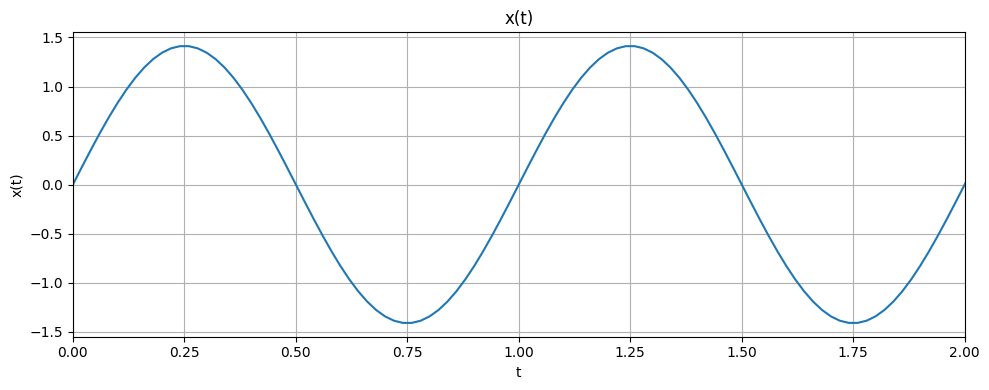

In [163]:
figure, axs = plt.subplots(1, 1, figsize=(10, 4))
axs.plot(tt, xx)
axs.set_xlabel('t')
axs.set_ylabel('x(t)')
axs.grid(True)
axs.set_title("x(t)")
axs.set_xlim(0, 2)
plt.tight_layout()
plt.show()

##### Grafico de la señal muestreada en el tiempo

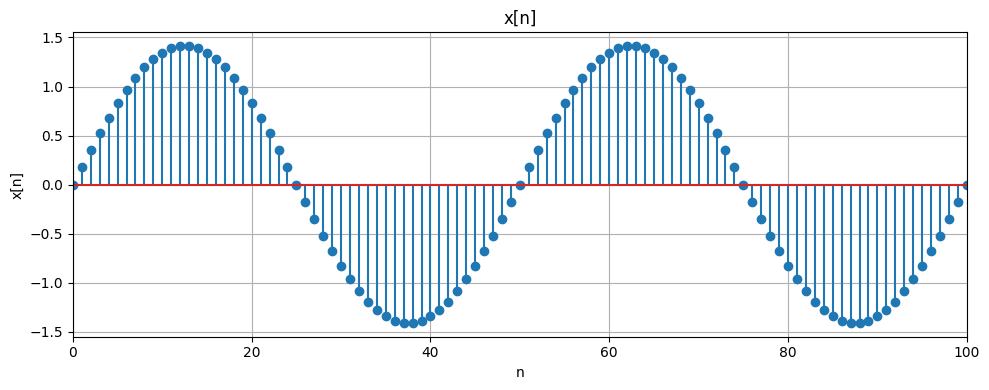

In [164]:
figure, axs = plt.subplots(1, 1, figsize=(10, 4))
axs.stem(xx)
axs.set_xlabel('n')
axs.set_ylabel('x[n]')
axs.set_xlim(0, 100)
axs.grid(True)
axs.set_title("x[n]")
plt.tight_layout()
plt.show()

El **error de cuantización** es la diferencia entre el valor analógico original y su representación discreta, introducida al mapear una señal continua a un número finito de niveles determinado por la resolución del ADC.

Definimos una resolución de 8 bits.

El rango del ADC debe cumplir $V_{FS} > 2 \cdot A_{MAX}$, y dado que $A_{MAX} = \sqrt{2} \text{ V}$:

$$V_{FS} = 3 \text{ V} > 2\sqrt{2} \approx 2.83 \text{ V}$$


El paso de cuantización $q$ del ADC se define como el cociente entre el rango de entrada $V_{FS}$ y el número de niveles $2^B$, donde $B = 12$ es la resolución en bits:

$$q = \frac{V_{FS}}{2^{B}}$$

In [165]:
BITS = 8
AMAX = np.sqrt(2)
VFS = 3
q = VFS/(2**BITS)

print(f"2 * AMAX = {AMAX*2}")
print(f"q = {q}")


2 * AMAX = 2.8284271247461903
q = 0.01171875


Para simular la cuantización dividimos y redondeamos por q, y volvemos a multiplicar por q para volver a obtener tensiones:

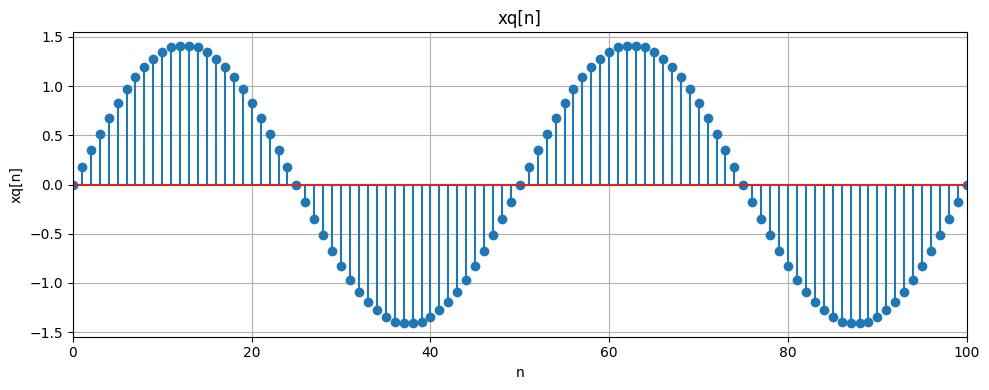

In [166]:
xx_q = np.round(xx / q) * q


figure, axs = plt.subplots(1, 1, figsize=(10, 4))
axs.stem(xx_q)
axs.set_xlabel('n')
axs.set_ylabel('xq[n]')
axs.set_xlim(0, 100)
axs.grid(True)
axs.set_title("xq[n]")
plt.tight_layout()
plt.show()

Con un paso de cuantización de 11 milivolts no vemos a simple vista diferencia entre la señal antes y después de cuantizar.

El error de cuantización $e[n]$ se define como la diferencia entre la señal cuantizada $x_q[n]$ y la señal original $x[n]$:

$$e[n] = x_q[n] - x[n]$$

y se encuentra acotado por:

$$-\frac{q}{2} \leq e[n] < \frac{q}{2}$$

Podemos calcularlo y ver su distribución:

Maximo error: 0.46*q
Minimo error: -0.46*q


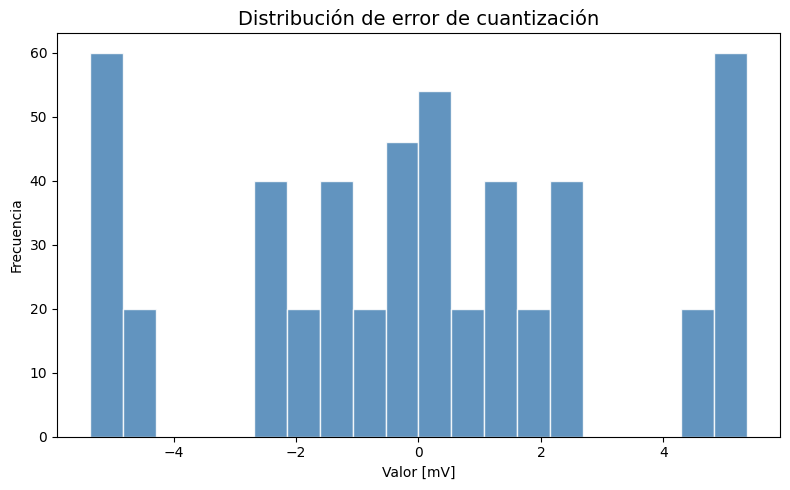

In [167]:
eq = xx_q - xx

print(f"Maximo error: {(np.max(eq) / q):.2f}*q")
print(f"Minimo error: {(np.min(eq) / q):.2f}*q")

plt.figure(figsize=(8, 5))
plt.hist(eq*1000, bins=20, color='steelblue', edgecolor='white', alpha=0.85)

plt.title('Distribución de error de cuantización', fontsize=14)
plt.xlabel('Valor [mV]')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Vemos que la distribución no es una distribución uniforme como se esperaría. Para que el error de cuantización tenga distribución uniforme la señal de entrada debe ser una señal completamente incorrelacionada, obviamente no es nuestro caso con nuestra señal senoidal sin ruido. Sin embargo, al agregarle ruido blanco podemos hacer que nuestra señal sea mas "incorrelacional".

Podemos comprobarlo:

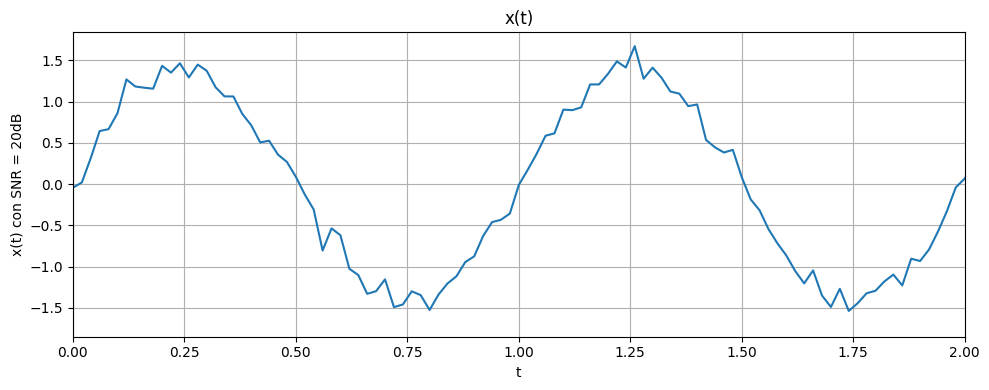

In [ ]:
xx, tt = pds_sen_ruidosa(nn = N, fs = fs, freq = 1, Amax = np.sqrt(2), dc = 0, phase = 0, SNR_db = 20)
xx_q = np.round(xx / q) * q
eq = xx_q - xx

figure, axs = plt.subplots(1, 1, figsize=(10, 4))
axs.plot(tt, xx)
axs.set_xlabel('t')
axs.set_ylabel('x(t)')
axs.grid(True)
axs.set_title("x(t) con SNR = 20dB")
axs.set_xlim(0, 2)
plt.tight_layout()
plt.show()

Maximo error: 0.50*q
Minimo error: -0.50*q


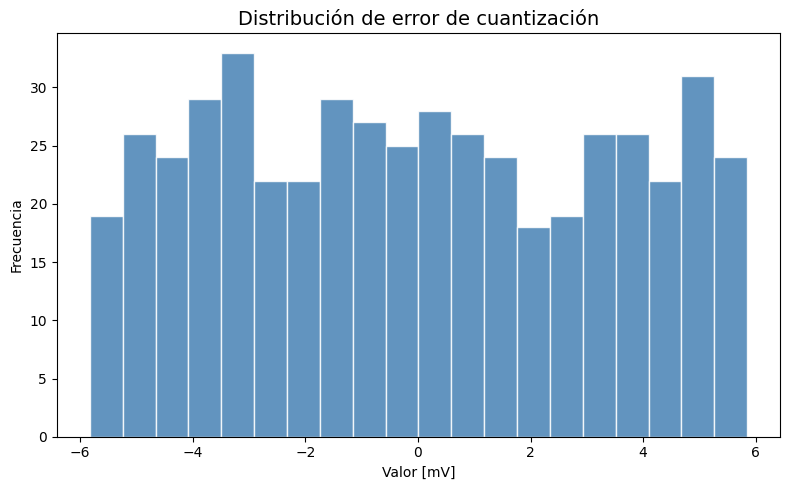

In [169]:
print(f"Maximo error: {(np.max(eq) / q):.2f}*q")
print(f"Minimo error: {(np.min(eq) / q):.2f}*q")

plt.figure(figsize=(8, 5))
plt.hist(eq*1000, bins=20, color='steelblue', edgecolor='white', alpha=0.85)

plt.title('Distribución de error de cuantización', fontsize=14)
plt.xlabel('Valor [mV]')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()